# **Tech Challenge Fase 1 | Case NPS Preditivo | Pós-Tech FIAP**

---

##### Análise Exploratória dos Dados (EDA)

Objetivo: explorar os dados com foco em negócio, identificar quais fatores operacionais mais impactam o NPS, onde estão os pontos de ruptura na experiência do cliente e que perfil de cliente tende a ser promotor ou detrator.

## 0. Imports e Configurações

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

os.makedirs('../reports/figures', exist_ok=True)
print('Configurações carregadas com sucesso.')

Configurações carregadas com sucesso.


## 1. Carregamento dos Dados

In [50]:
df = pd.read_csv('../desafio_nps_fase_1.csv')

print(f'Shape do dataset: {df.shape}')
print(f'Clientes únicos: {df["customer_id"].nunique()}')
print(f'Pedidos únicos:  {df["order_id"].nunique()}')
print(f'Regiões:         {sorted(df["customer_region"].unique())}')
df.head()

Shape do dataset: (2500, 19)
Clientes únicos: 2500
Pedidos únicos:  2500
Regiões:         ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2. Qualidade dos Dados

In [51]:
print('=== TIPOS E VALORES AUSENTES ===')
info = pd.DataFrame({
    'tipo': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info)
print(f'\nTotal de valores ausentes: {df.isnull().sum().sum()}')

=== TIPOS E VALORES AUSENTES ===
                              tipo  nulos  nulos_%
customer_id                  int64      0      0.0
customer_age                 int64      0      0.0
customer_region                str      0      0.0
customer_tenure_months       int64      0      0.0
order_id                     int64      0      0.0
order_value                float64      0      0.0
items_quantity               int64      0      0.0
discount_value             float64      0      0.0
payment_installments         int64      0      0.0
delivery_time_days           int64      0      0.0
delivery_delay_days          int64      0      0.0
freight_value              float64      0      0.0
delivery_attempts            int64      0      0.0
customer_service_contacts    int64      0      0.0
resolution_time_days         int64      0      0.0
nps_score                  float64      0      0.0
repeat_purchase_30d          int64      0      0.0
complaints_count             int64      0      0.

In [52]:
print('=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe().round(2)

=== ESTATÍSTICAS DESCRITIVAS ===


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


## 3. Distribuição do NPS - Promotores, Neutros e Detratores

O primeiro passo é entender como os clientes se distribuem pelas categorias NPS e qual é o NPS calculado da empresa.

In [53]:
def classificar_nps(score):
    if score >= 9:
        return 'Promotor'
    elif score >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

contagem = df['nps_categoria'].value_counts()
total = len(df)
promotores = contagem.get('Promotor', 0)
detratores = contagem.get('Detrator', 0)
nps_empresa = round((promotores - detratores) / total * 100, 1)

print('Distribuição NPS:')
for cat, qtd in contagem.items():
    print(f'  {cat}: {qtd} clientes ({qtd/total:.1%})')
print(f'\nNPS calculado da empresa: {nps_empresa}')

Distribuição NPS:
  Detrator: 2109 clientes (84.4%)
  Neutro: 281 clientes (11.2%)
  Promotor: 110 clientes (4.4%)

NPS calculado da empresa: -80.0


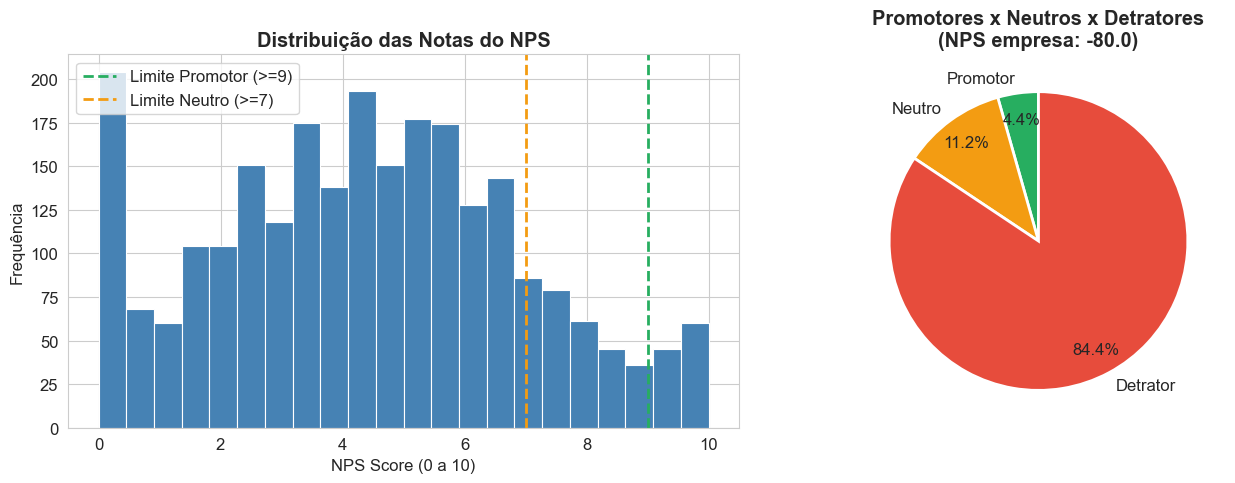

In [54]:
CORES = {'Promotor': '#27ae60', 'Neutro': '#f39c12', 'Detrator': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['nps_score'], bins=22, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].axvline(x=9, color='#27ae60', linestyle='--', linewidth=2, label='Limite Promotor (>=9)')
axes[0].axvline(x=7, color='#f39c12', linestyle='--', linewidth=2, label='Limite Neutro (>=7)')
axes[0].set_title('Distribuição das Notas do NPS', fontweight='bold')
axes[0].set_xlabel('NPS Score (0 a 10)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Gráfico de pizza
cats = contagem.reindex(['Promotor', 'Neutro', 'Detrator']).dropna()
axes[1].pie(
    cats.values,
    labels=cats.index,
    autopct='%1.1f%%',
    colors=[CORES[c] for c in cats.index],
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title(f'Promotores x Neutros x Detratores\n(NPS empresa: {nps_empresa})', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_distribuicao_nps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Fatores Logísticos vs NPS

### 4.1 Atraso na Entrega

**Pergunta de negócio:** O atraso na entrega é um fator crítico para a queda do NPS? A partir de quantos dias de atraso o cliente começa a virar detrator?

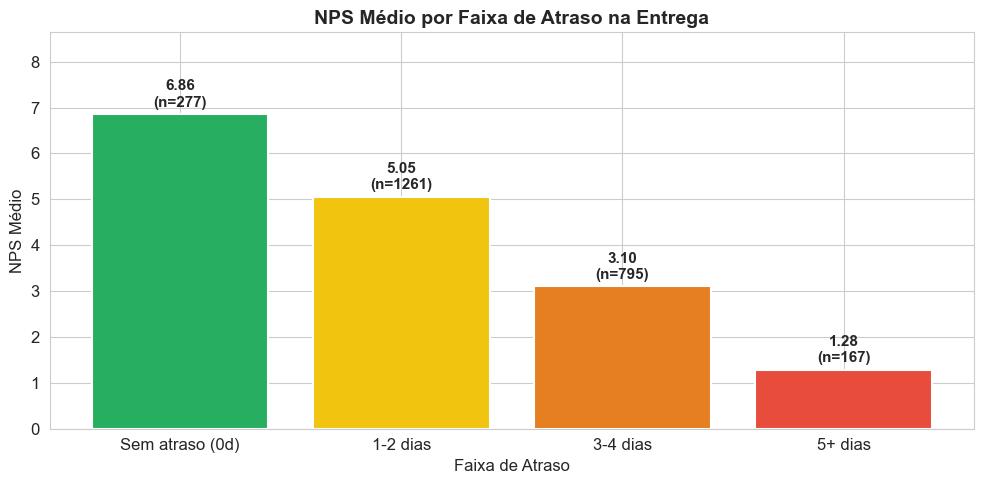

Insight: Clientes com 5+ dias de atraso têm NPS médio dramaticamente menor.
Ponto de ruptura: o NPS cai significativamente a partir de 3 dias de atraso.


In [55]:
# Agrupar atrasos em faixas
bins_atraso = [-1, 0, 2, 4, 100]
labels_atraso = ['Sem atraso (0d)', '1-2 dias', '3-4 dias', '5+ dias']
df['faixa_atraso'] = pd.cut(df['delivery_delay_days'], bins=bins_atraso, labels=labels_atraso)

nps_atraso = df.groupby('faixa_atraso', observed=True)['nps_score'].agg(['mean', 'count']).reset_index()
nps_atraso.columns = ['faixa_atraso', 'nps_medio', 'qtd_pedidos']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nps_atraso['faixa_atraso'], nps_atraso['nps_medio'],
              color=['#27ae60', '#f1c40f', '#e67e22', '#e74c3c'], edgecolor='white', linewidth=1.5)

for bar, (_, row) in zip(bars, nps_atraso.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row["nps_medio"]:.2f}\n(n={row["qtd_pedidos"]})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('NPS Médio por Faixa de Atraso na Entrega', fontweight='bold', fontsize=14)
ax.set_xlabel('Faixa de Atraso')
ax.set_ylabel('NPS Médio')
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig('../reports/figures/02_nps_por_atraso.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Clientes com 5+ dias de atraso têm NPS médio dramaticamente menor.')
print('Ponto de ruptura: o NPS cai significativamente a partir de 3 dias de atraso.')

### 4.2 Tentativas de Entrega

**Pergunta:** Múltiplas tentativas de entrega frustram o cliente e derrubam o NPS de alguma forma?

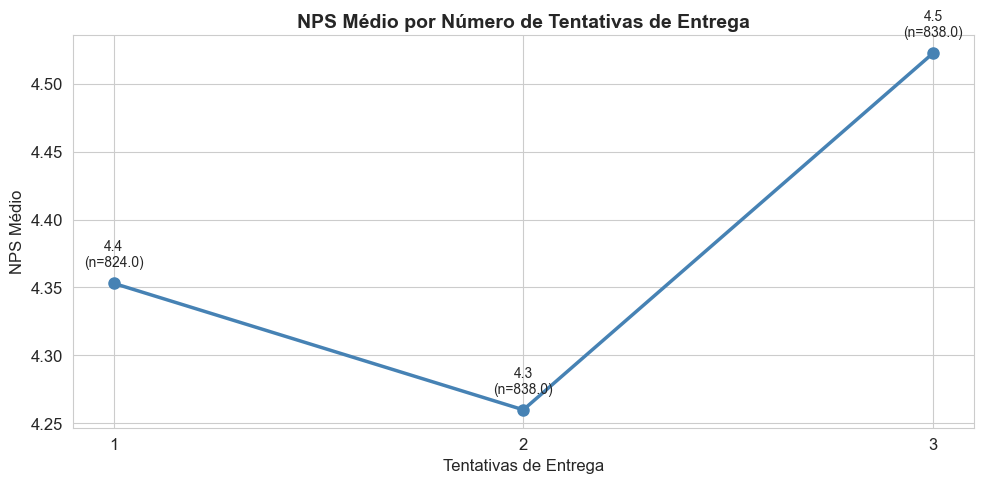

Não parecem haver diferenças claras no NPS médio entre 1, 2 ou 3 tentativas.
O NPS e a quantidade de pedidos também estão próximos, portanto não parece haver uma relação clara entre o número de tentativas e o NPS.


In [56]:
nps_tentativas = df.groupby('delivery_attempts')['nps_score'].agg(['mean', 'count']).reset_index()
nps_tentativas.columns = ['tentativas', 'nps_medio', 'qtd']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nps_tentativas['tentativas'], nps_tentativas['nps_medio'],
        marker='o', linewidth=2.5, markersize=8, color='steelblue')

for _, row in nps_tentativas.iterrows():
    ax.annotate(f'{row["nps_medio"]:.1f}\n(n={row["qtd"]})',
                xy=(row['tentativas'], row['nps_medio']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10)

ax.set_title('NPS Médio por Número de Tentativas de Entrega', fontweight='bold', fontsize=14)
ax.set_xlabel('Tentativas de Entrega')
ax.set_ylabel('NPS Médio')
ax.set_xticks(nps_tentativas['tentativas'])
plt.tight_layout()
plt.savefig('../reports/figures/03_nps_por_tentativas.png', dpi=150, bbox_inches='tight')
plt.show()

print('Não parecem haver diferenças claras no NPS médio entre 1, 2 ou 3 tentativas.' \
'\nO NPS e a quantidade de pedidos também estão próximos, portanto não parece haver uma relação clara entre o número de tentativas e o NPS.')

---
## 5. Fatores de Atendimento vs NPS

### 5.1 Contatos com o Atendimento

**Pergunta:** Clientes que precisam contatar o SAC têm NPS mais baixo? Quantos contatos representam um ponto crítico?

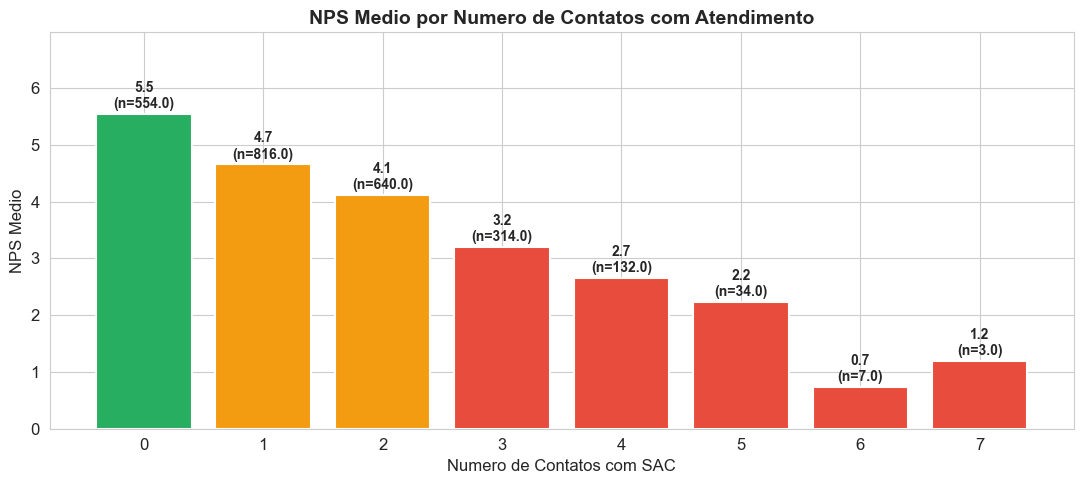

Insight: Clientes que nao precisaram contatar o SAC (0 contatos) tem o maior NPS medio.
Cada contato adicional representa uma experiencia negativa.


In [57]:
nps_contatos = df.groupby('customer_service_contacts')['nps_score'].agg(['mean', 'count']).reset_index()
nps_contatos.columns = ['contatos', 'nps_medio', 'qtd']

# Limitar a ate 7 contatos para visualizacao limpa
nps_contatos_plot = nps_contatos[nps_contatos["contatos"] <= 7]

fig, ax = plt.subplots(figsize=(11, 5))
cores_contatos = ['#27ae60' if c == 0 else ('#f39c12' if c <= 2 else '#e74c3c')
                  for c in nps_contatos_plot['contatos']]
bars = ax.bar(nps_contatos_plot['contatos'].astype(str), nps_contatos_plot['nps_medio'],
              color=cores_contatos, edgecolor='white', linewidth=1.5)

for bar, (_, row) in zip(bars, nps_contatos_plot.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["nps_medio"]:.1f}\n(n={row["qtd"]})', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('NPS Medio por Numero de Contatos com Atendimento', fontweight='bold', fontsize=14)
ax.set_xlabel('Numero de Contatos com SAC')
ax.set_ylabel('NPS Medio')
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig('../reports/figures/04_nps_por_contatos_sac.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Clientes que nao precisaram contatar o SAC (0 contatos) tem o maior NPS medio.')
print('Cada contato adicional representa uma experiencia negativa.')

### 5.2 Reclamações vs NPS

**Pergunta:** O número de reclamações registradas tem relação linear com a queda no NPS?

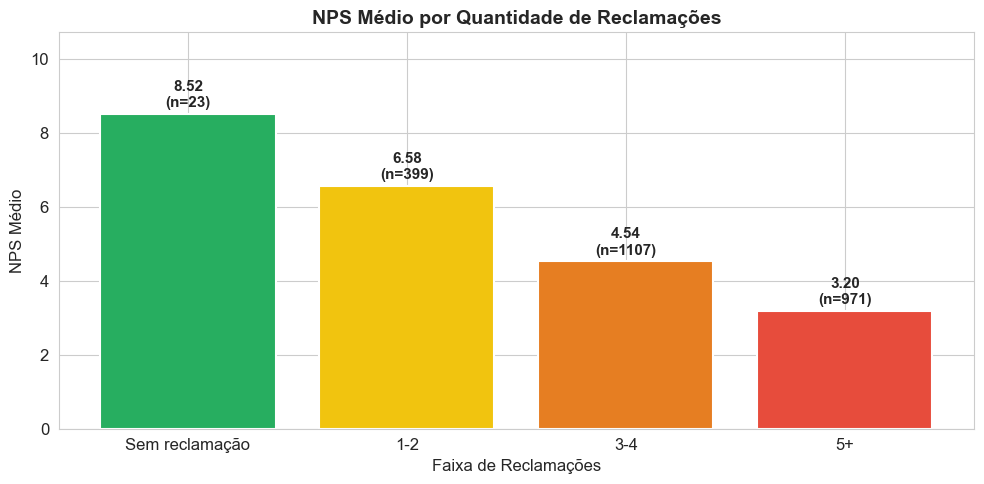

In [58]:
# Agrupar reclamações em faixas para visualização
bins_rec = [-1, 0, 2, 4, 100]
labels_rec = ['Sem reclamação', '1-2', '3-4', '5+']
df['faixa_reclamacoes'] = pd.cut(df['complaints_count'], bins=bins_rec, labels=labels_rec)

nps_rec = df.groupby('faixa_reclamacoes', observed=True)['nps_score'].agg(['mean', 'count']).reset_index()
nps_rec.columns = ['faixa', 'nps_medio', 'qtd']

fig, ax = plt.subplots(figsize=(10, 5))
cores_rec = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(nps_rec['faixa'], nps_rec['nps_medio'], color=cores_rec,
              edgecolor='white', linewidth=1.5)

for bar, (_, row) in zip(bars, nps_rec.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row["nps_medio"]:.2f}\n(n={row["qtd"]})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('NPS Médio por Quantidade de Reclamações', fontweight='bold', fontsize=14)
ax.set_xlabel('Faixa de Reclamações')
ax.set_ylabel('NPS Médio')
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig('../reports/figures/05_nps_por_reclamacoes.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Tempo de Resolução vs NPS

**Pergunta:** Clientes cujos problemas demoram mais para ser resolvidos avaliam pior?

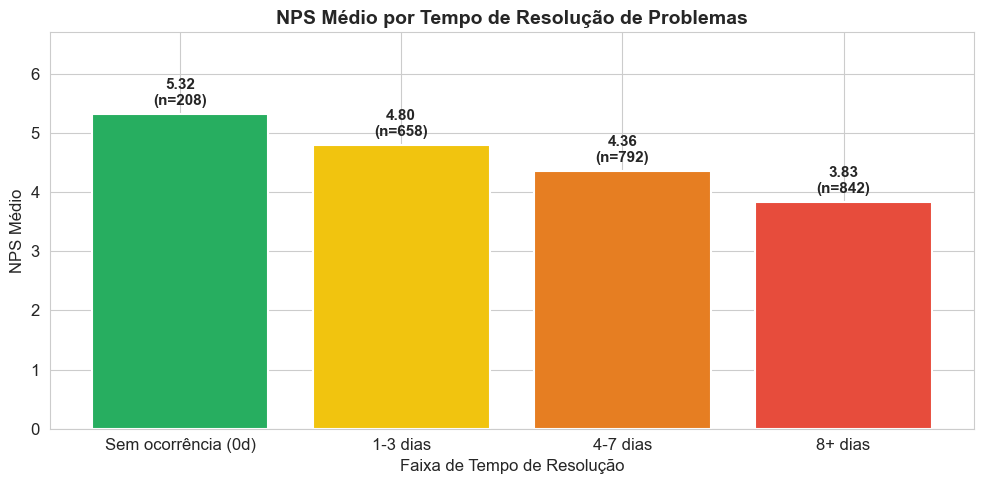

In [59]:
bins_res = [-1, 0, 3, 7, 100]
labels_res = ['Sem ocorrência (0d)', '1-3 dias', '4-7 dias', '8+ dias']
df['faixa_resolucao'] = pd.cut(df['resolution_time_days'], bins=bins_res, labels=labels_res)

nps_resolucao = df.groupby('faixa_resolucao', observed=True)['nps_score'].agg(['mean', 'count']).reset_index()
nps_resolucao.columns = ['faixa', 'nps_medio', 'qtd']

fig, ax = plt.subplots(figsize=(10, 5))
cores_res = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(nps_resolucao['faixa'], nps_resolucao['nps_medio'],
              color=cores_res, edgecolor='white', linewidth=1.5)

for bar, (_, row) in zip(bars, nps_resolucao.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row["nps_medio"]:.2f}\n(n={row["qtd"]})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('NPS Médio por Tempo de Resolução de Problemas', fontweight='bold', fontsize=14)
ax.set_xlabel('Faixa de Tempo de Resolução')
ax.set_ylabel('NPS Médio')
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig('../reports/figures/06_nps_por_resolucao.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Perfil do Cliente vs NPS

### 6.1 NPS por Região Geográfica

**Pergunta:** Existem diferenças regionais no NPS? Alguma região está sistematicamente pior?

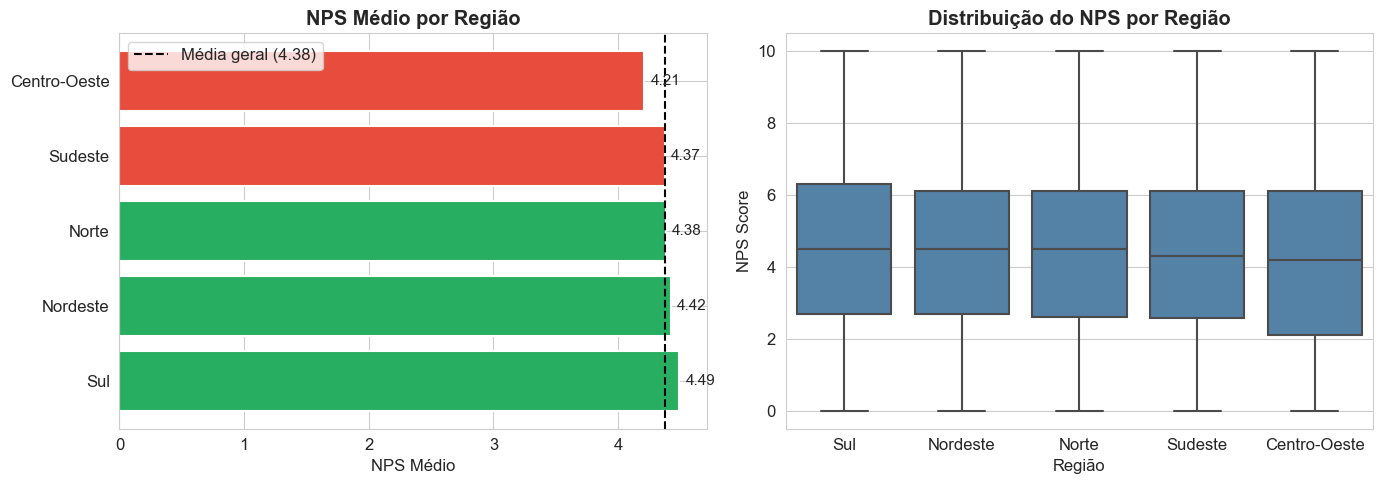

      regiao  nps_medio  qtd   desvio
         Sul   4.490979  521 2.516739
    Nordeste   4.421649  485 2.434829
       Norte   4.382609  506 2.485931
     Sudeste   4.373846  520 2.491552
Centro-Oeste   4.209829  468 2.625968


In [ ]:
nps_regiao = df.groupby('customer_region')['nps_score'].agg(['mean', 'count', 'std']).reset_index()
nps_regiao.columns = ['regiao', 'nps_medio', 'qtd', 'desvio']
nps_regiao = nps_regiao.sort_values('nps_medio', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NPS médio por região
cores_regiao = ['#27ae60' if v >= nps_regiao['nps_medio'].mean() else '#e74c3c'
                for v in nps_regiao['nps_medio']]
bars = axes[0].barh(nps_regiao['regiao'], nps_regiao['nps_medio'],
                    color=cores_regiao, edgecolor='white', linewidth=1.5)
axes[0].axvline(x=nps_regiao['nps_medio'].mean(), color='black', linestyle='--',
                linewidth=1.5, label=f'Média geral ({nps_regiao["nps_medio"].mean():.2f})')
for bar, (_, row) in zip(bars, nps_regiao.iterrows()):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{row["nps_medio"]:.2f}', va='center', fontsize=11)
axes[0].set_title('NPS Médio por Região', fontweight='bold')
axes[0].set_xlabel('NPS Médio')
axes[0].legend()

# Distribuição boxplot por região (sns.boxplot suporta order)
ordem_regiao = nps_regiao['regiao'].tolist()
sns.boxplot(data=df, x='customer_region', y='nps_score', order=ordem_regiao,
            ax=axes[1], color='steelblue', linewidth=1.5)
axes[1].set_title('Distribuição do NPS por Região', fontweight='bold')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('NPS Score')

plt.tight_layout()
plt.savefig('../reports/figures/07_nps_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

print(nps_regiao.to_string(index=False))

print('Insight: Diferente do que era esperado, o NPS médio varia muito pouco entre as regiões.')
print('Isso mostra que o atraso no transporte está afetando todas as regiões.')

### 6.2 NPS por Tempo de Relacionamento (Antiguidade)

**Pergunta:** Clientes mais antigos são mais tolerantes ou têm expectativas maiores?

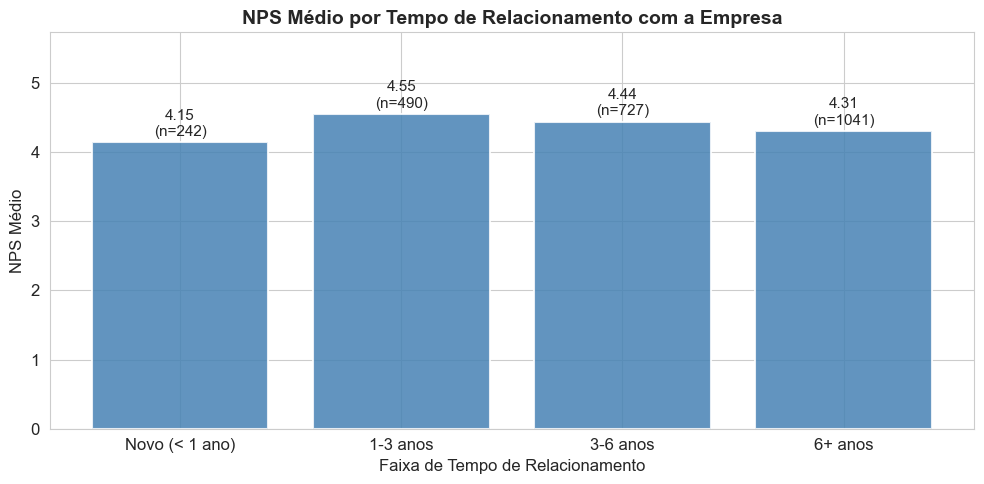

In [63]:
bins_tenure = [0, 12, 36, 72, 999]
labels_tenure = ['Novo (< 1 ano)', '1-3 anos', '3-6 anos', '6+ anos']
df['faixa_tenure'] = pd.cut(df['customer_tenure_months'], bins=bins_tenure, labels=labels_tenure)

nps_tenure = df.groupby('faixa_tenure', observed=True)['nps_score'].agg(['mean', 'count']).reset_index()
nps_tenure.columns = ['faixa', 'nps_medio', 'qtd']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nps_tenure['faixa'], nps_tenure['nps_medio'],
              color='steelblue', edgecolor='white', linewidth=1.5, alpha=0.85)

for bar, (_, row) in zip(bars, nps_tenure.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["nps_medio"]:.2f}\n(n={row["qtd"]})',
            ha='center', va='bottom', fontsize=11)

ax.set_title('NPS Médio por Tempo de Relacionamento com a Empresa', fontweight='bold', fontsize=14)
ax.set_xlabel('Faixa de Tempo de Relacionamento')
ax.set_ylabel('NPS Médio')
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig('../reports/figures/08_nps_por_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 NPS por Faixa Etária

**Pergunta:** A idade do cliente influencia a nota NPS? Clientes mais jovens são mais exigentes?

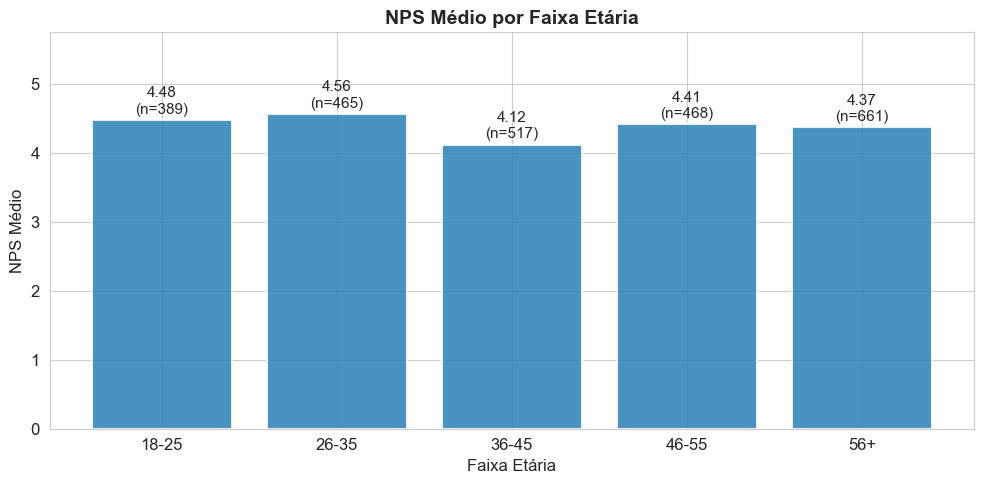

In [64]:
bins_idade = [0, 25, 35, 45, 55, 100]
labels_idade = ['18-25', '26-35', '36-45', '46-55', '56+']
df['faixa_idade'] = pd.cut(df['customer_age'], bins=bins_idade, labels=labels_idade)

nps_idade = df.groupby('faixa_idade', observed=True)['nps_score'].agg(['mean', 'count']).reset_index()
nps_idade.columns = ['faixa', 'nps_medio', 'qtd']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nps_idade['faixa'], nps_idade['nps_medio'],
              color='#2980b9', edgecolor='white', linewidth=1.5, alpha=0.85)

for bar, (_, row) in zip(bars, nps_idade.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["nps_medio"]:.2f}\n(n={row["qtd"]})',
            ha='center', va='bottom', fontsize=11)

ax.set_title('NPS Médio por Faixa Etária', fontweight='bold', fontsize=14)
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('NPS Médio')
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig('../reports/figures/09_nps_por_idade.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Valor do Pedido x NPS

**Pergunta:** Talvez não haja relação, mas o valor do pedido tem relação com NPS?

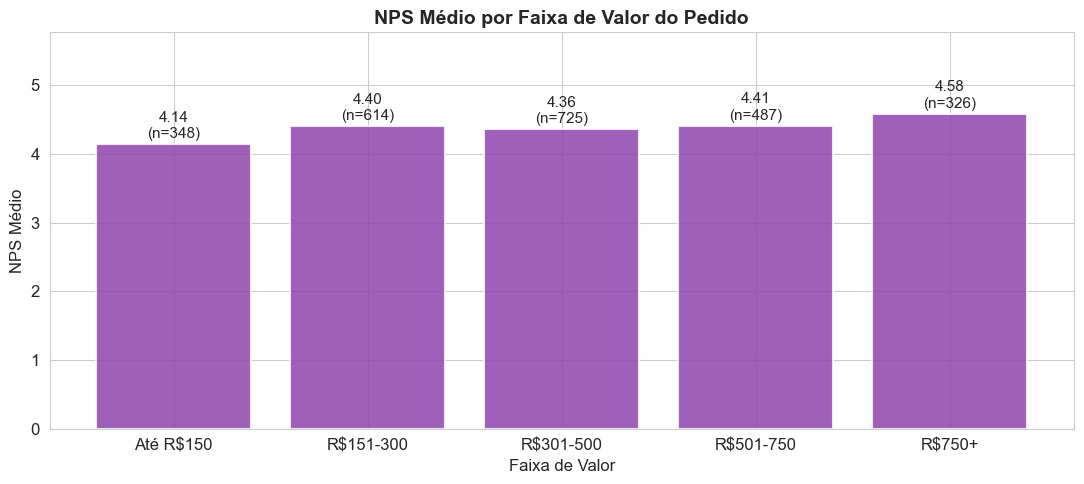

In [66]:
bins_valor = [0, 150, 300, 500, 750, 9999]
labels_valor = ['Até R$150', 'R$151-300', 'R$301-500', 'R$501-750', 'R$750+']
df['faixa_valor'] = pd.cut(df['order_value'], bins=bins_valor, labels=labels_valor)

nps_valor = df.groupby('faixa_valor', observed=True)['nps_score'].agg(['mean', 'count']).reset_index()
nps_valor.columns = ['faixa', 'nps_medio', 'qtd']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(nps_valor['faixa'], nps_valor['nps_medio'],
              color='#8e44ad', edgecolor='white', linewidth=1.5, alpha=0.85)

for bar, (_, row) in zip(bars, nps_valor.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["nps_medio"]:.2f}\n(n={row["qtd"]})',
            ha='center', va='bottom', fontsize=11)

ax.set_title('NPS Médio por Faixa de Valor do Pedido', fontweight='bold', fontsize=14)
ax.set_xlabel('Faixa de Valor')
ax.set_ylabel('NPS Médio')
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig('../reports/figures/10_nps_por_valor_pedido.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Desconto do Pedido x NPS

**Pergunta:** O desconto do pedido pode gerar um melhor NPS?

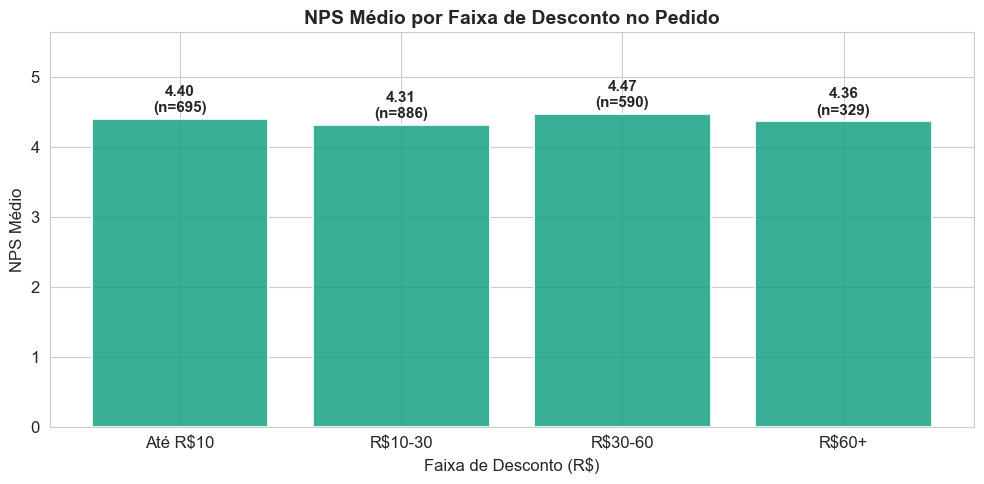

Correlação discount_value x nps_score: 0.0251


In [ ]:
bins_desc = [0, 10, 30, 60, 999]
labels_desc = ['Até R$10', 'R$10-30', 'R$30-60', 'R$60+']
df['faixa_desconto'] = pd.cut(df['discount_value'], bins=bins_desc, labels=labels_desc)

nps_desc = df.groupby('faixa_desconto', observed=True)['nps_score'].agg(['mean', 'count']).reset_index()
nps_desc.columns = ['faixa', 'nps_medio', 'qtd']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nps_desc['faixa'], nps_desc['nps_medio'],
              color='#16a085', edgecolor='white', linewidth=1.5, alpha=0.85)

for bar, (_, row) in zip(bars, nps_desc.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["nps_medio"]:.2f}' + chr(10) + '(n=' + str(int(row['qtd'])) + ')',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('NPS Médio por Faixa de Desconto no Pedido', fontweight='bold', fontsize=14)
ax.set_xlabel('Faixa de Desconto (R$)')
ax.set_ylabel('NPS Médio')
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig('../reports/figures/13_nps_por_desconto.png', dpi=150, bbox_inches='tight')
plt.show()

print('Aparentemente também sem relação.')

---
## 7. Mapa de Correlação

**Pergunta:** Quais variáveis numéricas têm maior correlação com o NPS? Isso norteia a seleção de features para o modelo.

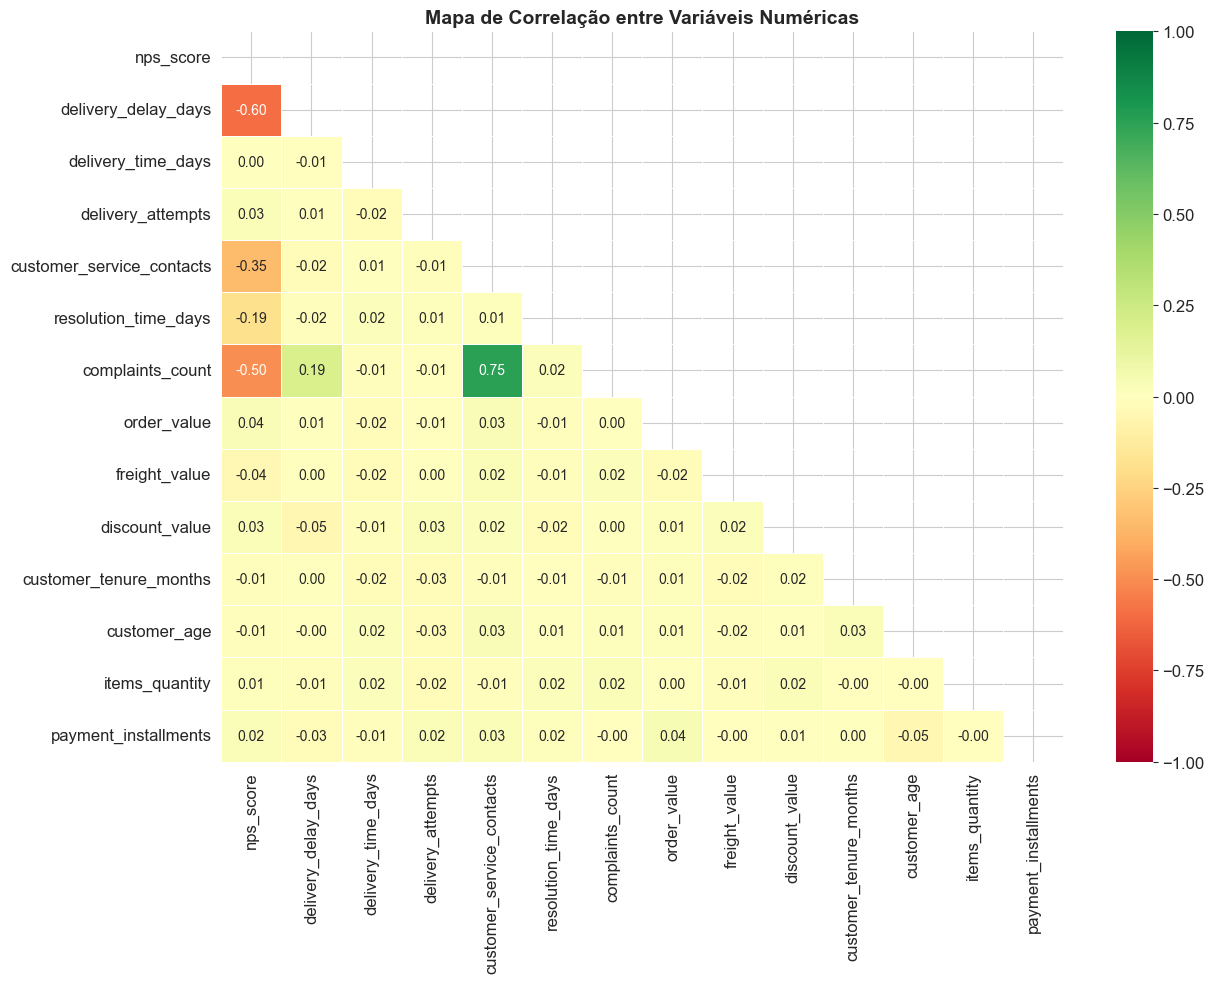


Correlação com nps_score (ordenada):
order_value                  0.0370
delivery_attempts            0.0277
discount_value               0.0251
payment_installments         0.0237
items_quantity               0.0115
delivery_time_days           0.0009
customer_tenure_months      -0.0097
customer_age                -0.0099
freight_value               -0.0411
resolution_time_days        -0.1914
customer_service_contacts   -0.3508
complaints_count            -0.4968
delivery_delay_days         -0.5973
Name: nps_score, dtype: float64


In [72]:
colunas_correlacao = [
    'nps_score',
    'delivery_delay_days',
    'delivery_time_days',
    'delivery_attempts',
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count',
    'order_value',
    'freight_value',
    'discount_value',
    'customer_tenure_months',
    'customer_age',
    'items_quantity',
    'payment_installments'
]

corr = df[colunas_correlacao].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, ax=ax,
    annot_kws={'size': 10}, linewidths=0.5
)
ax.set_title('Mapa de Correlação entre Variáveis Numéricas', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/11_mapa_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelação com nps_score (ordenada):')
print(corr['nps_score'].drop('nps_score').sort_values(ascending=False).round(4))

---
## 8. Perfil de Promotores vs Detratores

Comparação direta entre as médias das variáveis para cada categoria NPS — responde a pergunta: **que tipo de cliente tende a ter NPS mais alto ou mais baixo?**

In [70]:
variaveis_perfil = [
    'delivery_delay_days', 'delivery_time_days', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days', 'complaints_count',
    'order_value', 'customer_tenure_months', 'freight_value'
]

perfil = df.groupby('nps_categoria')[variaveis_perfil].mean().round(2).T
# Ordenar colunas para exibição
cols_ordem = [c for c in ['Promotor', 'Neutro', 'Detrator'] if c in perfil.columns]
perfil = perfil[cols_ordem]

print('=== PERFIL MÉDIO POR CATEGORIA NPS ===')
print(perfil.to_string())

=== PERFIL MÉDIO POR CATEGORIA NPS ===
nps_categoria              Promotor  Neutro  Detrator
delivery_delay_days            0.72    1.05      2.41
delivery_time_days             7.94    8.26      7.99
delivery_attempts              2.15    2.01      2.00
customer_service_contacts      0.67    1.01      1.63
resolution_time_days           3.70    4.62      5.69
complaints_count               2.27    2.69      4.44
order_value                  468.08  458.17    429.31
customer_tenure_months        63.00   59.83     61.43
freight_value                 37.05   38.06     38.30


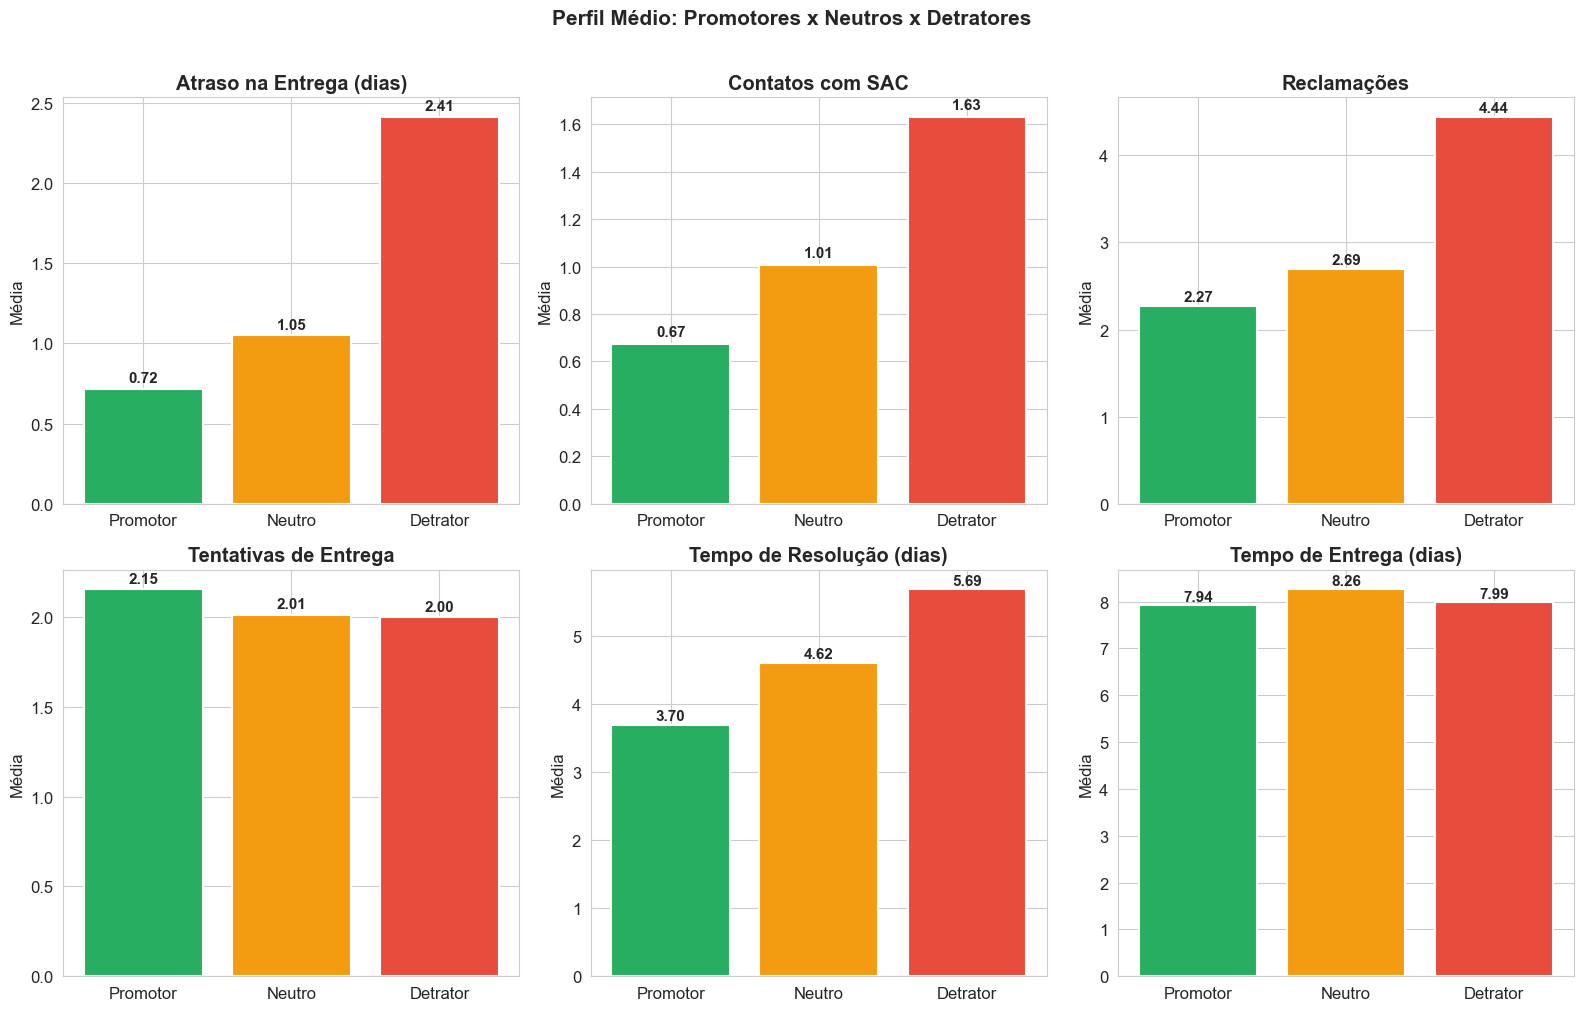

In [71]:
# Visualizar as diferenças mais impactantes
variaveis_destaque = [
    ('delivery_delay_days', 'Atraso na Entrega (dias)'),
    ('customer_service_contacts', 'Contatos com SAC'),
    ('complaints_count', 'Reclamações'),
    ('delivery_attempts', 'Tentativas de Entrega'),
    ('resolution_time_days', 'Tempo de Resolução (dias)'),
    ('delivery_time_days', 'Tempo de Entrega (dias)')
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cores_cat = {'Promotor': '#27ae60', 'Neutro': '#f39c12', 'Detrator': '#e74c3c'}

for idx, (var, titulo) in enumerate(variaveis_destaque):
    medias = df.groupby('nps_categoria')[var].mean()
    cats = [c for c in ['Promotor', 'Neutro', 'Detrator'] if c in medias.index]
    vals = [medias[c] for c in cats]
    cores = [cores_cat[c] for c in cats]

    bars = axes[idx].bar(cats, vals, color=cores, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                       f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[idx].set_title(titulo, fontweight='bold')
    axes[idx].set_ylabel('Média')

plt.suptitle('Perfil Médio: Promotores x Neutros x Detratores', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/12_perfil_promotores_detratores.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Visualizar as diferenças mais impactantes - Versão reduzida
variaveis_destaque = [
    ('delivery_delay_days', 'Atraso na Entrega (dias)'),
    ('customer_service_contacts', 'Contatos com SAC'),
    ('complaints_count', 'Reclamações'),
    ('resolution_time_days', 'Tempo de Resolução (dias)')
]

---
## 9. Principais Insights — Resumo para o Negócio

> Esta seção traduz os achados da análise em linguagem de negócio, como se estivéssemos apresentando para um gerente de operações que não entende estatística.

---

### O que mais derruba o NPS?

**1. Atraso na entrega é o principal vilão**
Clientes que recebem o pedido no prazo (sem atraso) têm NPS médio significativamente mais alto do que aqueles com atrasos de 5+ dias, cujo NPS cai para próximo de zero. O ponto de ruptura claro está em **3+ dias de atraso** — a partir daí, a satisfação despenca. Recomendação: priorizar SLA de entrega, especialmente para regiões com maior variância logística.

**2. Contato com o SAC sinaliza problema — não solução**
Clientes que não precisaram contatar o atendimento (0 contatos) têm o NPS mais alto. Cada ligação ou chat adicional representa um sinal de que algo deu errado e não foi resolvido na primeira tentativa. O foco deve ser na **resolução no primeiro contato** e, mais importante, na **eliminação da causa raiz** que obriga o cliente a ligar.

**3. Reclamações destroem a satisfação progressivamente**
Clientes sem reclamações têm NPS muito acima da média. A queda é progressiva com cada reclamação adicional. Isso indica que o processo de pós-venda e a gestão de ocorrências precisam de atenção.

**4. Múltiplas tentativas de entrega frustram o cliente**
Três ou mais tentativas de entrega geram uma experiência negativa clara. Isso pode indicar problemas de endereçamento, janelas de entrega incompatíveis com a rotina do cliente ou falhas do transportador.

### Que perfil de cliente tem NPS mais alto ou mais baixo?

**Promotores (NPS alto) tendem a:**
- Receber no prazo ou com mínimo atraso
- Não precisar contatar o SAC
- Ter zero ou poucas reclamações
- Ser clientes mais antigos (maior tolerância + maior confiança na marca)

**Detratores (NPS baixo) tendem a:**
- Ter atraso na entrega, especialmente 5+ dias
- Ter feito múltiplos contatos com o atendimento
- Ter registrado várias reclamações
- Ter exigido 3+ tentativas de entrega

### Existem diferenças regionais?

Sim — algumas regiões apresentam NPS médio consistentemente abaixo da média geral, sugerindo gargalos logísticos regionais que merecem investigação operacional específica.

### O que fazer com esses insights?

| Área | Ação Recomendada |
|------|------------------|
| **Logística** | Monitorar atrasos em tempo real e acionar o cliente proativamente antes de ele reclamar |
| **Atendimento** | Investir em FCR (First Call Resolution) e reduzir tempo de resolução |
| **Produto/Ops** | Melhorar processo de tentativas de entrega — oferecer janelas de horário flexíveis |
| **CRM** | Identificar clientes em risco (alto atraso + contatos SAC) para ação preventiva antes do NPS ser coletado |

> **Próximo passo:** Construir um modelo preditivo para antecipar quais clientes têm alta probabilidade de ser detratores, antes da coleta do NPS. Ver `03_modelo_preditivo.ipynb`.